In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import sklearn
sklearn.set_config(display='text')

댓글을 군집화해 분석해 볼 것이다. 댓글 분석은 왜 필요할까? 분석해서 어디에 활용할 수 있을까? 다음과 같은 상황을 생각해 보자.

수백 수천 개 댓글을 다 읽어야 한다면?  
댓글 속에 제품에 대한 관심을 빈도수로 추출해야 한다면?  
쇼핑몰에서 제품 관련 이벤트를 진행할 때 고객이 어떤 제품을 선호하는지 알고 싶다면?  
고객 DB와 연계해 이벤트나 마케닝 세그먼트로 활용한다면?  
향후 마케팅 전략을 세울 때 활용한다면?

데이터는 IT 교육 사이트인 인프런의 새해 다짐 이벤트 댓글을 사용한다. 정답 레이블이 없는 데이터를 분류하고 시각화하는 방법에 초점을 맞출 것이다. 분석하려는 데이터는 정답 레이블이 없으므로 비지도 학습 군집화를 실습한다.

# 데이터 불러와서 전처리 하기

## 데이터 불러오기

In [2]:
df = pd.read_csv('./data/inflearn-event.csv')
df.shape

(2449, 1)

In [3]:
df.head()

,text
0,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\r\n관심강의...
1,"2020년 목표: C++ 열심히 공부해서, 학교에서 꼭 A 맞기..!! \r\n관심..."
2,2020년 목표 : 리액트 공부하기
3,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급
4,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!


In [4]:
df.tail()

,text
2444,"작년 한해도 일이 바쁘다, 야근해서 힘들다는 핑계로 ***님의 JPA 강의를 또 스..."
2445,저는 졸업을 1년 남기고 있는 컴퓨터공학과 학생입니다. 졸업 프로젝트로 웹/앱 개발...
2446,"에프터 이펙트를 써본 적은 있는데, 매번 기초만 배우다 말았어요. 이걸 할 줄 안다..."
2447,저번에 인프런에서 페이스북 마케팅 강의를 듣고 많은 도움을 받았습니다. 마케팅 업무...
2448,인프런 0호 팀원이에요!\r\n그동안 서비스 개발 때문에 js 를 많이 했었는데 앞...


## 중복된 글 제거하기

온라인으로 수집한 데이터는 다양한 이유로 중복 생성 될 수 있다. 웹사이트에서 전송 버튼을 여러 번 누르거나, 새로 고침을 하거나, 네트워크나 UX 관련된 오류 문제가 발생되기도 한다. 중복 데이터가 있으면 빈도 분석이 제대로 되지 않기 때문에 중복 데이터를 제거한다.

중복되는 데이터가 있는지 확인한다.

In [5]:
print(len(df.text), len(set(df.text)))

2449 2410


판다스의 drop_duplicates() 메소드로 데이터의 중복을 제거할 수 있다.  
keep 속성의 기본값은 `first`이고 중복되는 데이터에 첫 번째 데이터를 제외하고 모두 제거하고 `last`는 마지막 데이터를 제외하고 모두 제거한다. 만약에 중복되는 데이터를 모두 제거하고 싶다면 `False`를 사용하면 된다.

In [6]:
print(df.shape)
df = df.drop_duplicates(['text'], keep='last')
print(df.shape)

(2449, 1)
(2410, 1)


## 소문자로 변환하기

전처리할 때는 원본을 따로 보존하는 것을 추천한다. 원본과 전처리 결과를 비교해 볼 수 있고 망쳤을 때 복원할 수 있기 때문이다.

In [7]:
df['origin_text'] = df.text
df.head()

,text,origin_text
0,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\r\n관심강의...,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\r\n관심강의...
1,"2020년 목표: C++ 열심히 공부해서, 학교에서 꼭 A 맞기..!! \r\n관심...","2020년 목표: C++ 열심히 공부해서, 학교에서 꼭 A 맞기..!! \r\n관심..."
3,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급
4,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!
5,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!


파이썬은 같은 단어라도 대문자냐 소문자냐에 따라 다른 글자로 인식하므로 lower() 메소드로 모두 소문자로 변경한다.

In [8]:
df['text'] = df.text.str.lower()
df.head()

,text,origin_text
0,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\r\n관심강의...,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\r\n관심강의...
1,"2020년 목표: c++ 열심히 공부해서, 학교에서 꼭 a 맞기..!! \r\n관심...","2020년 목표: C++ 열심히 공부해서, 학교에서 꼭 A 맞기..!! \r\n관심..."
3,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급
4,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!
5,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!


'파이썬', 'python'과 같이 의미는 같으나 표기가 다르게 되어 있는 단어도 하나로 통일하기 위해서 replace() 메소드로 치환한다.

In [9]:
df['text'] = df.text.str.replace('python', '파이썬').str.replace('react', '리액트').str.replace('pandas', '판다스').str.replace('javascript', '자바스크립트'
    ).str.replace('java', '자바').str.replace('mongodb', '몽고DB').str.replace('django', '장고')
df.head()

,text,origin_text
0,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\r\n관심강의...,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\r\n관심강의...
1,"2020년 목표: c++ 열심히 공부해서, 학교에서 꼭 a 맞기..!! \r\n관심...","2020년 목표: C++ 열심히 공부해서, 학교에서 꼭 A 맞기..!! \r\n관심..."
3,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급
4,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!
5,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!


이 댓글 이벤트에는 '관심강의'라는 텍스트가 있다. 대부분 관심강의 뒤에 강의명을 적었으므로 '관심강의'를 기준으로 이전 텍스트는 제거하고 이후 텍스트를 새로운 변수에 담는, 문자열 분리로 관심강의를 분리해 보자.
실수 방지를 위해 'course'라는 새로운 열에 담아서 진행했으며, '관심 강의'나 '관심 강좌'에 대해서도 똑같이 처리하고 특수 문자인 ':'는 빈 문자로 변경한다.

In [10]:
df['course'] = df.text.apply(lambda x: x.split('관심강의')[-1])
df['course'] = df.course.apply(lambda x: x.split('관심 강의')[-1])
df['course'] = df.course.apply(lambda x: x.split('관심 강좌')[-1])
df['course'] = df.course.str.replace(':', '')

In [11]:
df[['text', 'course']].head()

,text,course
0,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\r\n관심강의...,스프링 웹 mvc
1,"2020년 목표: c++ 열심히 공부해서, 학교에서 꼭 a 맞기..!! \r\n관심...",***c++
3,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! 우리를 위한 프로그래밍 파이썬 중급
4,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!,2020년 목표 돌머리 비전공자가 멋진 전공자 되기!
5,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!,2020 년목표 비전공자(경영)가 전공자(it) 되기!!!


search_keyword에 course 열에 저장된 관심강의에서 검색할 과목 이름을 저장하고 반복문을 실행해서 관심강의에 검색할 과목 이름을 contains() 메소드로 포함하고 있을 경우 검색어를 열 이름으로 하는 열에 True를 그렇치 않으면 False를 넣어준다.

In [12]:
search_keyword = ['파이썬', '크롤링', '넘파이', '판다스', '시각화', '데이터분석', '몽고DB', '머신러닝', '딥러닝', '자연어', 'llm', 'rag', 'langgraph', 'neo4j']
for keyword in search_keyword:
    df[keyword] = df.course.str.contains(keyword)

In [13]:
df.head()

,text,origin_text,course,파이썬,크롤링,넘파이,판다스,시각화,데이터분석,몽고DB,머신러닝,딥러닝,자연어,llm,rag,langgraph,neo4j
0,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\r\n관심강의...,2020년 목표: 스프링 열심히 공부하서 직장에서 사랑받고 싶어요!!\r\n관심강의...,스프링 웹 mvc,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,"2020년 목표: c++ 열심히 공부해서, 학교에서 꼭 a 맞기..!! \r\n관심...","2020년 목표: C++ 열심히 공부해서, 학교에서 꼭 A 맞기..!! \r\n관심...",***c++,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! : 우리를 위한 프로그래밍 : 파이썬 중급,40대 프로그래밍 시작! 우리를 위한 프로그래밍 파이썬 중급,True,False,False,False,False,False,False,False,False,False,False,False,False,False
4,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!,2020년 목표 : 돌머리 비전공자가 멋진 전공자 되기!,2020년 목표 돌머리 비전공자가 멋진 전공자 되기!,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!,2020 년목표: 비전공자(경영)가 전공자(it) 되기!!!,2020 년목표 비전공자(경영)가 전공자(it) 되기!!!,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [14]:
df[df.머신러닝 & df.딥러닝].head()

,text,origin_text,course,파이썬,크롤링,넘파이,판다스,시각화,데이터분석,몽고DB,머신러닝,딥러닝,자연어,llm,rag,langgraph,neo4j
45,sw 개발자입니다. 자기개발 및 업무 환경 개선을 위해 공부하고 싶습니다.\r\n관...,SW 개발자입니다. 자기개발 및 업무 환경 개선을 위해 공부하고 싶습니다.\r\n관...,"모두를 위한 딥러닝 - deep reinforcement learning, 그 외...",True,False,False,False,False,False,False,True,True,False,False,False,False,False
59,올해 졸업하기 전에 머신러닝을 마스터하고 싶습니다.\r\n관심강의: 모두를 위한 딥...,올해 졸업하기 전에 머신러닝을 마스터하고 싶습니다.\r\n관심강의: 모두를 위한 딥...,"모두를 위한 딥러닝 - deep reinforcement learning, 그 외...",True,False,False,False,False,False,False,True,True,False,False,False,False,False
236,금융인을 꿈꾸는 인문대생인데 인프런을 통해 그 꿈에 날개를 달 수 있으면 좋겠습니다...,금융인을 꿈꾸는 인문대생인데 인프런을 통해 그 꿈에 날개를 달 수 있으면 좋겠습니다...,금융인을 꿈꾸는 인문대생인데 인프런을 통해 그 꿈에 날개를 달 수 있으면 좋겠습니다...,False,False,False,False,False,False,False,True,True,False,False,False,False,False
335,딥러닝에 관심이 생겨 구글링 중 인프런에 좋은 강의를 발견했습니다. \r\n열심히 ...,딥러닝에 관심이 생겨 구글링 중 인프런에 좋은 강의를 발견했습니다. \r\n열심히 ...,모두를 위한 딥러닝 - 기본적인 머신러닝과 딥러닝 강좌,False,False,False,False,False,False,False,True,True,False,False,False,False,False
348,"평생 개발자 하렵니다. 인프런에서 잘 배워서!\r\n관심강의: 파이썬 인공지능, 머...","평생 개발자 하렵니다. 인프런에서 잘 배워서!\r\n관심강의: 파이썬 인공지능, 머...","파이썬 인공지능, 머신러닝, 딥러닝 제대로 배워요!, 데이터 과학부터 인공지능까지!",True,False,False,False,False,False,False,True,True,False,False,False,False,False


이번에는 정규표현식을 사용해 '파이썬', '판다스', '데이터분석'라는 텍스트가 들어간 데이터를 찾아보자. contains() 메소드를 사용하면 정규표현식을 사용해 원하는 키워드가 들어간 데이터를 찾을 수 있다.

In [15]:
df_python = df[df.text.str.contains(r'.*(파이썬|판다스|데이터분석).*')]
df_python.shape

(435, 17)

In [16]:
df[df.text.str.contains(r'.*(머신러닝|딥러닝).*')].shape

(184, 17)

댓글에 특정 키워드가 포함되어있나 검색해서 있으면 True(1), 없으면 False(0)를 넣은 파생 변수들의 True의 빈도수를 sum() 메소드로 계산한다.

In [17]:
df[search_keyword].sum().sort_values(ascending=False)

파이썬          402
머신러닝         130
크롤링           56
딥러닝           48
시각화           30
데이터분석         21
판다스            6
자연어            4
몽고DB           2
넘파이            0
llm            0
rag            0
langgraph      0
neo4j          0
dtype: int64

In [18]:
text = df.loc[df.데이터분석, 'text']
for t in text:
    print(t)
    print('-' * 100)

신입 개발자인데, 현업에서 사용하는 기술의 대부분을 인프런을 통해 배웠습니다.
2020년도 인프런과 함께 하고 싶습니다.
관심강의 : 데이터분석, 텐서플로우, 파이썬 강의
----------------------------------------------------------------------------------------------------
2020년에는 데이터분석 관련한 실력을 쌓고싶습니다!
관심강의 : 파이썬, 판다스, 데이터분석, 머신러닝
----------------------------------------------------------------------------------------------------
데이터분석 2년차가 되는데 작년에 파이썬 강의를 담아놓고 그대로 1년간 방치... 올해는 꼭 완강하고 실습해서 개발자에게 의존하지 않고 혼자 크롤링&분석 해내고 싶어요! 
관심강의: 공공데이터로 파이썬 데이터분석 시작하기, database 1&2 - mysql
----------------------------------------------------------------------------------------------------
이직을 위해 개발자 공부를 하려고 합니다~!
관심강의: 파이썬/데이터분석
----------------------------------------------------------------------------------------------------
데이터 분석을 끝내고 싶다.
관심강의: sql/db(mysql) 기본부터 파이썬/데이터분석 활용까지!
----------------------------------------------------------------------------------------------------
사람들이 무슨 생각을 하는지 알고 싶네요.
관심강의 sql/db(mysql) 기본부터 파이썬/데이터분석 활용까지 입니다.
----------------------------

In [19]:
text = df.loc[df.판다스, 'text']
for t in text:
    print(t)
    print('-' * 100)

2020년에는 데이터분석 관련한 실력을 쌓고싶습니다!
관심강의 : 파이썬, 판다스, 데이터분석, 머신러닝
----------------------------------------------------------------------------------------------------
취미로 안드로이드 개발하는 사람입니다. 자바로 작성하다 보니, kotlin이 안드로이드 기반언어로 바뀌어서 새로 배워보려고 합니다.
관심강의 : kotlin, 판다스, 파이썬, c언어
----------------------------------------------------------------------------------------------------
판다스 라입러리에 관심이 많아서 배워보려 합니다 관심강의 : *** 판다스
----------------------------------------------------------------------------------------------------
2020년!! 올 해는 빅데이터 분석 전문가 되기!!
관심강의 : 파이썬, 판다스
----------------------------------------------------------------------------------------------------
2020년 목표  파이썬 을  활용해  데이터 분석 작업을 진행하고 싶습니다.  관심강의:파이썬 판다스 관련 강좌 입니다
----------------------------------------------------------------------------------------------------
저는 백세시대에 조금 더 오랫동안 it일을 하기위해서 it전략기획에서 데이터분석가로 커리어 전환을 준비하고 있습니다. 인프런의 수많은 좋은 강의중 파이썬 기반의 데이터분석을 공부하기 위하여 인프런을 활용하고 있습니다. 대한민국 최고의 데이터분석가 되는 그날까지 인프런과 함께 하겟습니다.
관심강의 : 파이썬 판다스 데

# 벡터화 하기

이제 빈도 계산을 위해 텍스트 데이터를 벡터화 하자. 먼저 단어 가방 모형에 단어를 토큰화해서 담아야 한다.

In [20]:
'파이썬 데이터 분석'.split()

['파이썬', '데이터', '분석']

사이킷런의 CountVectorizer()를 통해 벡터화 한다.

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

In [22]:
# 사이킷런 라이브러리의 CountVectorizer를 사용해서 텍스트 데이터를 수치적인 벡터로 변환하는 설정을 한다.
# 단순히 단어의 빈도를 세는 것을 넘어, 여러 단어가 묶인 n-gram을 추출하도록 설정되 있다.
vectorizer = CountVectorizer(
    # 분석의 단위를 '단어'로 설정한다.
    # 텍스트를 공백 기반의 단어로 나누어 특징(feature)을 추출한다. 다른 옵션으로 문자를 단위로 하는 'char' 등이 있다.
    analyzer='word',
    # 단어를 분리하는 로직이다. None일 경우 사이킷런의 기본 정규표현식을 사용해서 단어를 분리한다.
    tokenizer=None,
    # 정규표현식 등을 이용해 텍스트를 사전에 정제하는 과정이다.
    preprocessor=None,
    # 불용어 처리 방법을 설정한다.
    stop_words=None,
    # 전체 문서들 중에서 최소 2개 이상의 문서에 등장하는 단어(또는 n-gram)만 추출한다. 한 번만 나타나는 표현은 노이즈로 간주하여 제외한다.
    min_df=2,
    # 이 코드의 핵심 설정으로 연속된 단어의 묶음을 3개부터 6개까지 추출한다.
    ngram_range=(3, 6),
    # 데이터셋이 커서 많은 조합이 생길 경우 메모리 부족을 방지하고 계산 속도를 높이기 위해 빈도수가 높은 순서대로 상의 2,000개만 사용한다.
    max_features=2000,
)
vectorizer

CountVectorizer(max_features=2000, min_df=2, ngram_range=(3, 6))

CountVectorizer 객체를 만들었으며 df['course']만 벡터화 한다. shape으로 확인해 보면 text에 있는 단어로든 2,410개의 행과 2,000개의 열을 만들 수 있다.

In [23]:
feature_vector = vectorizer.fit_transform(df['course'])
feature_vector.shape

(2410, 2000)

CountVectorizer 객체에서 get_feature_names_out() 메소드로 단어 사전을 구성하는 단어 또는 단어의 묶음을 얻어올 수 있고 단어가 3개에서 6개까지 묶여서 나온다.

In [24]:
vocab = vectorizer.get_feature_names_out()
print(len(vocab))
vocab[:10]

2000


array(['12개 만들면서 배우는', '12개 만들면서 배우는 ios', '12개 만들면서 배우는 ios 아이폰',
       '12개 만들면서 배우는 ios 아이폰 개발', '12개를 만들며 배우는', '12개를 만들며 배우는 swift4',
       '12개를 만들며 배우는 swift4 ios11', '12개를 만들며 배우는 swift4 ios11 아이폰',
       '2018 do it', '2018 do it 안드로이드'], dtype=object)

전체 단어 가방에서 해당 댓글마다 등장하는 단어에 대한 빈도수를 확인해 보자.  
각 행은 댓글을 의미하며, 등장하는 단어의 빈도수를 확인할 수 있다. 0은 등장하지 않는다는 뜻인데, 단어 가방으로 벡터화하면 희소 행렬이 만들어진다.

In [25]:
pd.DataFrame(feature_vector.toarray(), columns=vocab)

,12개 만들면서 배우는,12개 만들면서 배우는 ios,12개 만들면서 배우는 ios 아이폰,12개 만들면서 배우는 ios 아이폰 개발,12개를 만들며 배우는,12개를 만들며 배우는 swift4,12개를 만들며 배우는 swift4 ios11,12개를 만들며 배우는 swift4 ios11 아이폰,2018 do it,2018 do it 안드로이드,...,활용한 다양한 자동화,활용한 다양한 자동화 어플리케이션,활용한 다양한 자동화 어플리케이션 제작하기,활용한 데이터분석과 it보안,활용한 리액트 native,활용한 리액트 native 개발,활용한 메신져 만들기,활용한 메신져 만들기 android,활용한 파이썬 프로그래밍,활용한 파이썬 프로그래밍 완벽
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2405,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2406,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2407,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2408,0,0,0,0,0,0,0,0,0,0,...,1,1,1,0,0,0,0,0,0,0


ngram_range를 (3, 6)으로 설정해서 3개 ~ 6개 토큰을 묶어서 사용했기 때문에 중복되는 강의가 있다.  
넘파이의 sum() 메소드로 위에서 구한 단어 벡터를 더하면 단어가 전체에서 등장하는 횟수를 알 수 있으므로 단어 가방에 몇 개의 단어가 들어 있는지 확인할 수 있다.

In [26]:
dist = np.sum(feature_vector, axis=0)
df_freq = pd.DataFrame(dist, columns=vocab)
df_freq

,12개 만들면서 배우는,12개 만들면서 배우는 ios,12개 만들면서 배우는 ios 아이폰,12개 만들면서 배우는 ios 아이폰 개발,12개를 만들며 배우는,12개를 만들며 배우는 swift4,12개를 만들며 배우는 swift4 ios11,12개를 만들며 배우는 swift4 ios11 아이폰,2018 do it,2018 do it 안드로이드,...,활용한 다양한 자동화,활용한 다양한 자동화 어플리케이션,활용한 다양한 자동화 어플리케이션 제작하기,활용한 데이터분석과 it보안,활용한 리액트 native,활용한 리액트 native 개발,활용한 메신져 만들기,활용한 메신져 만들기 android,활용한 파이썬 프로그래밍,활용한 파이썬 프로그래밍 완벽
0,2,2,2,2,2,2,2,2,2,2,...,13,13,12,2,8,8,2,2,2,2


T로 전치해서 행과 열의 위치를 바꿔주고 빈도수를 정렬해 가장 많이 듣고싶어하는 강의를 확인한다.

In [27]:
df_freq.T.sort_values(by=0, ascending=False).head(10)

,0
스프링 데이터 jpa,59
nodebird sns 만들기,58
파이썬 머신러닝 완벽,49
리액트로 nodebird sns,49
리액트로 nodebird sns 만들기,49
머신러닝 완벽 가이드,49
함수형 프로그래밍과 자바스크립트,48
파이썬 머신러닝 완벽 가이드,48
프로그래밍과 자바스크립트 es6,48
함수형 프로그래밍과 자바스크립트 es6,48


결과를 보면 두 번 이상 나오는 것들이 있다(nodebird sns, 파이썬 머신러닝). 앞에서 ngram_range로 3개 이상의 단어를 묶어서 가져오도록 했기 때문에 중복이 생긴 것이다. 이 중복을 처리해 주자.

In [28]:
df_freq_T = df_freq.T.reset_index()
df_freq_T.columns = ['course', 'freq']
df_freq_T.head(10)

,course,freq
0,12개 만들면서 배우는,2
1,12개 만들면서 배우는 ios,2
2,12개 만들면서 배우는 ios 아이폰,2
3,12개 만들면서 배우는 ios 아이폰 개발,2
4,12개를 만들며 배우는,2
5,12개를 만들며 배우는 swift4,2
6,12개를 만들며 배우는 swift4 ios11,2
7,12개를 만들며 배우는 swift4 ios11 아이폰,2
8,2018 do it,2
9,2018 do it 안드로이드,2


중복을 제거하기 위해 강의명에서 지식공유자 이름(`***`)을 빈 문자열로 변경하고 lambda 식을 사용해서 course(관심강의명)를 split() 메소드로 나눈 다음 앞에서 4개까지만 텍스트를 가져와서 다시 공백을 삽입해서 join() 메소드로 합친다.

In [29]:
df_freq_T['course_find'] = df_freq_T.course.str.replace('***', '')
df_freq_T['course_find'] = df_freq_T.course_find.apply(lambda x: ' '.join(x.split()[:4]))
df_freq_T.sort_values(['course_find', 'freq'], ascending=False).head(10)

,course,freq,course_find
1999,활용한 파이썬 프로그래밍 완벽,2,활용한 파이썬 프로그래밍 완벽
1998,활용한 파이썬 프로그래밍,2,활용한 파이썬 프로그래밍
1997,활용한 메신져 만들기 android,2,활용한 메신져 만들기 android
1996,활용한 메신져 만들기,2,활용한 메신져 만들기
1995,활용한 리액트 native 개발,8,활용한 리액트 native 개발
1994,활용한 리액트 native,8,활용한 리액트 native
1993,활용한 데이터분석과 it보안,2,활용한 데이터분석과 it보안
1991,활용한 다양한 자동화 어플리케이션,13,활용한 다양한 자동화 어플리케이션
1992,활용한 다양한 자동화 어플리케이션 제작하기,12,활용한 다양한 자동화 어플리케이션
1990,활용한 다양한 자동화,13,활용한 다양한 자동화


drop_duplicates() 메소드로 첫 번째 강의만 남기고 나머지 중복은 삭제한다.  
데이터프레임 전체 행이 똑같은지가 아니라, 'course_find' 열과 'freq' 열의 값이 모두 일치하는 경우만 중복으로 간주한다.

In [30]:
print(df_freq_T.shape)
df_course = df_freq_T.drop_duplicates(['course_find', 'freq'], keep='first')
print(df_course.shape)

(2000, 3)
(1441, 3)


In [31]:
df_course = df_course.sort_values(by='freq', ascending=False)
df_course

,course,freq,course_find
1086,스프링 데이터 jpa,59,스프링 데이터 jpa
299,nodebird sns 만들기,58,nodebird sns 만들기
831,리액트로 nodebird sns,49,리액트로 nodebird sns
1772,파이썬 머신러닝 완벽,49,파이썬 머신러닝 완벽
878,머신러닝 완벽 가이드,49,머신러닝 완벽 가이드
...,...,...,...
977,보안 취미로 해킹 시리즈,2,보안 취미로 해킹 시리즈
984,부트 개념과 활용 스프링 프레임워크,2,부트 개념과 활용 스프링
993,부트의 개념과 활용,2,부트의 개념과 활용
1,12개 만들면서 배우는 ios,2,12개 만들면서 배우는 ios


전처리가 다 되었다면 csv 파일로 저장한다.

In [32]:
df_course.to_csv('./data/event_course_freq.csv')

# TF-IDF로 가중치를 주어 벡터화 하기

앞에서는 빈도수를 기준으로 벡터를 만들었다. 전체 문서에 자주 등장하지 않더라고 해당 문서에 자주 등장하는 단어라련 중요한 단어로 볼 수 있다.

In [33]:
from sklearn.feature_extraction.text import TfidfTransformer

smooth_idf=False는 분모가 0이 되는 것을 방지하기 위해 수식에 1을 더하는 보정 연산을 수행하지 않는다. 1을 더하는 처리를 생략하므로, 데이터 내의 모든 단어가 최소 한 번은 문서 집합 내에 존재해야 오류가 나지 않는다.  
결과적으로 특정 단어가 아주 적은 문서에 등장할 때, smooth_idf=True일 때보다 해당 단어에 더 높은 가중치를 부여하는 경향이 있다.

In [34]:
tfidfTrans = TfidfTransformer(smooth_idf=False)
tfidfTrans

TfidfTransformer(smooth_idf=False)

In [35]:
feature_tfidf = tfidfTrans.fit_transform(feature_vector)
feature_tfidf.shape

(2410, 2000)

전체 단어 가방 모형에 등장하는 단어에 대한 TF-IDF 가중치를 반영한 결과를 보자. feature_tfidf.toarray()로 배열을 만든뒤 데이터프레임으로 만들어 확인한다.

In [36]:
feature_freq = pd.DataFrame(feature_tfidf.toarray(), columns=vocab)
feature_freq.head()

,12개 만들면서 배우는,12개 만들면서 배우는 ios,12개 만들면서 배우는 ios 아이폰,12개 만들면서 배우는 ios 아이폰 개발,12개를 만들며 배우는,12개를 만들며 배우는 swift4,12개를 만들며 배우는 swift4 ios11,12개를 만들며 배우는 swift4 ios11 아이폰,2018 do it,2018 do it 안드로이드,...,활용한 다양한 자동화,활용한 다양한 자동화 어플리케이션,활용한 다양한 자동화 어플리케이션 제작하기,활용한 데이터분석과 it보안,활용한 리액트 native,활용한 리액트 native 개발,활용한 메신져 만들기,활용한 메신져 만들기 android,활용한 파이썬 프로그래밍,활용한 파이썬 프로그래밍 완벽
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
df_tfidf = pd.DataFrame(feature_freq.sum())
df_tfidf = df_tfidf.sort_values(by=0, ascending=False)
df_tfidf.head(10)

,0
스프링 데이터 jpa,35.717385
파이썬 실전 활용,28.131806
nodebird sns 만들기,27.218283
파이썬 머신러닝 완벽,24.804873
머신러닝 완벽 가이드,24.804873
리액트로 nodebird sns,24.775145
리액트로 nodebird sns 만들기,24.775145
파이썬 머신러닝 완벽 가이드,23.905135
함수형 프로그래밍과 자바스크립트,19.841529
프로그래밍과 자바스크립트 es6,19.841529


# 군집화하기

## KMeans

K평균(KMeans) 군집화는 머신러닝 비지도학습 기법 중 하나로, 주어진 데이터를 K개로 묶는 알고리즘이다. 군집 간 거리 차이의 분산을 최소화하는 방식으로 군집을 만들어 간다.

데이터 집합에서 K개의 데이터 개체를 임의로 추출하고 각 클러스터의 중심점(centroid)를 초기값으로 설정한다. 그리고 K개의 군집과 데이테 집합의 거리를 구해 각 개체가 어느 중심점과 가장 유사도가 높은지 계산한다. 그렇게 찾은 중심점으로 다시 데이터 군집의 중심점을 계한하는 방법을 반복한다. 이때 거리를 구하는 방법 유클리드 거리 측정 방법을 사용한다.

그러면 K평균 군집화를 사용해 보자. 사이킷런에서 KMeans를 import 한다.  
반복문의 진행 상태를 프로그래스 바(progress bar)로 보여주는 라이브러리 tqdm의 trange를 import 하면 작업이 얼마나 남았는지 시각적으로 알 수 있다.

In [38]:
from sklearn.cluster import KMeans
from tqdm import trange

KMeans 알고리즘에서 inertia_는 클러스터링(군집화)이 얼마나 잘 이루어졌는지를 평가하는 대표적인 내부 평가 지표로 클러스터 내의 데이터들이 중심점에 얼마나 조밀하게 모여 있는지를 나타낸다.  
inertia_가 낮을수록 데이터들이 중심 주변에 빽빽하게 모여 있음을 의미하고 모든 포인트가 중심점에 완벽히 겹치면 0이 된다.

In [39]:
inertia = []
start = 2
end = 70

for i in trange(start, end + 1):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(feature_tfidf)
    # print(kmeans.inertia_)
    inertia.append(kmeans.inertia_)

100%|██████████| 69/69 [00:05<00:00, 12.70it/s]


위에서 구한 inertia_ 값을 시각화해 보자. x축에는 클러스터의 수를 y축에는 이너셔(inertia) 값을 넣어 그린다.

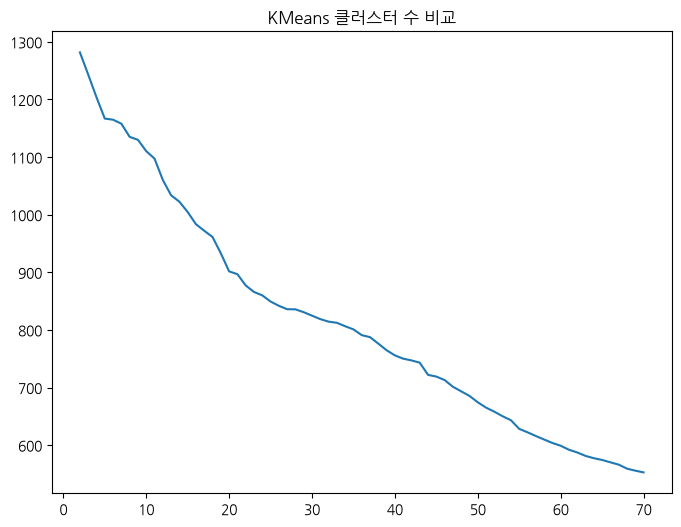

In [40]:
plt.figure(figsize=(8, 6))
plt.plot(range(start, end + 1), inertia)
plt.title('KMeans 클러스터 수 비교')
plt.show()

x축에 속하는 클러스터 수가 커질수록 inertia 값이 감소한다. 보통 이상적인 방법이라면 inertia 값이 꺾이는 부분을 찾아 클러스터의 수를 정해준다. inertia 값이 급격하게 꺾이는 지점을 찾아 군집으로 정하는 것을 팔꿈치가 꺾이는 것에 비유해 엘보(elbow) 기법이라고 부른다. 하지만 현실 세계 데이터를 다루다 보면 이론처럼 급격하게 꺾이는 지점이 나타나지 않을 수 있다. 또 클러스터의 수가 너무 많으면 군집화 값을 관리하기 어려울 수도 있다.

이 실습의 목적은 비슷한 강의끼리 분류하는 것이다. 급격하게 inertia 값이 꺾이는 부분을 찾기는 어렵지만 강의를 나눌 때 50개 정도를 n_clusters 값으로 넣어준 후 값을 키우거나 줄여서 테스트해 보자. 결과는 cluster라는 새로운 열을 만들어서 저장한다.

In [51]:
n_clusters = 50
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(feature_tfidf)
predict = kmeans.predict(feature_tfidf)
df['cluster'] = predict

0번 그룹에 1,706개 데이터가 있고 2번 그룹에 46개의 데이터가 있다.

In [42]:
df.cluster.value_counts().head(10)

cluster
0     1721
9       46
2       42
5       37
27      31
1       30
3       27
20      25
7       25
11      23
Name: count, dtype: int64

## MiniBatchKMeans

데이터가 많다면 군집화 속도가 오래 걸린다. 이때 배치 사이즈를 지정해서 군집화를 진행하면 조금 빠르게 작업할 수 있다.

In [43]:
from sklearn.cluster import MiniBatchKMeans

In [44]:
b_inertia = []

for i in trange(start, end + 1):
    mkmeans = MiniBatchKMeans(n_clusters=i, random_state=42)
    mkmeans.fit(feature_tfidf)
    b_inertia.append(mkmeans.inertia_)

100%|██████████| 69/69 [00:13<00:00,  5.03it/s]


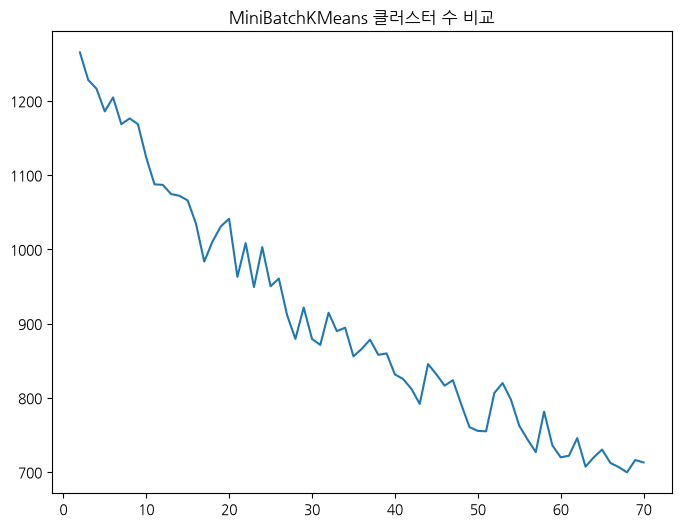

In [45]:
plt.figure(figsize=(8, 6))
plt.plot(range(start, end + 1), b_inertia)
plt.title('MiniBatchKMeans 클러스터 수 비교')
plt.show()

inertia 값을 시각화하는 이유는 엘보 기법을 사용하기 위해서이다. y축의 inertia 값은 가장 가까운 군집의 중심과 데이터의 거리 제곱합니다. 중심과 데이터의 거리가 가까울수록 군집이 잘 되었다고 볼 수 있기 때문에 inertia 값이 작을수록 군집이 잘 되었다고 평가한다.

반복문을 통해 inertia 값을 구할 때 첫 군집은 랜덤하게 군집의 중심을 설정하기 때문에 높은 값이 나올 수밖에 없다. 다음 군집 부터는 거리를 계산해 군집의 중심을 이동하므로 중심과 군집은 점점 가까워지고 값이 점점 낮아지는 그래프가 그려진다. 이상적인 군집이라면 마치 팔꿈치가 꺾이듯이 이 값이 낮아지는 클러스터가 나타난다. 급격하게 꺾이는 부분이 있다면 그 값을 참고해 클러스터의 수를 정한다. 전처리가 잘 된 정형 데이터라면 팔꿈치 처럼 급격하게 꺾이는 부분이 이상적으로 등장할 수 있지만 예제에서 사용하는 비정형 텍스트 데이터에서는 이론처럼 급격히 꺾이는 부분은 나타나지 않는다.

yellowbrick이라는 머신러닝 시각화 도구를 사용해서 시각화 해 볼 수도 있다.

yellowbrick은 사이킷런과 Matplotlib을 결합하여 머신러닝 모델의 진단, 평가, 데이터 분석 과정을 시각화해 주는 라이브러리로 기존에는 시각화를 하려면 Matplotlib이나 Seaborn으로 일일이 코드를 길게 작성해야 했지만, yellowbrick은 사이킷런과 동일한 방식을 사용하여 직관적인 진단 차트를 생성한다.

yellowbrick 라이브러리를 사용하기 위해 설치하고 import 한다.

In [46]:
# !pip install yellowbrick
# 2026년 8월 31일 현재 사이킷런 1.9.0 버전에서는 yellowbrick이 동작하지 않으므로 사이킷런 다운그레이드가 필요하다.
# !pip install scikit-learn==1.7.2
# !pip install scikit-learn==1.3.2

In [47]:
from yellowbrick.cluster import KElbowVisualizer

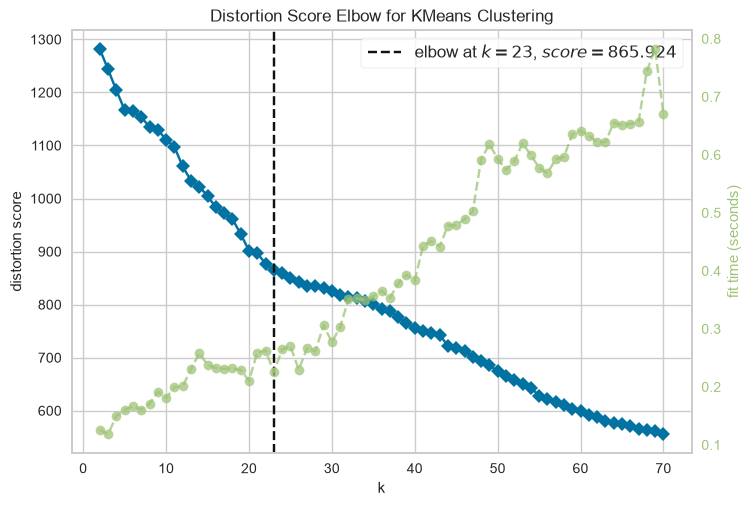

In [48]:
kelbow = KElbowVisualizer(kmeans, k=(start, end + 1))
kelbow.fit(feature_tfidf.toarray())
kelbow.show()
plt.show()

KElbowVisualizer 라이브러리를 실행하면 2개의 꺾은선 그래프와 수직 점선이 표시된다.  
x축은 클러스터의 개수, y축(왼쪽, 파란색 실선)은 선택한 평가 지표 값, y축(오른쪽, 녹색 점선)은 모델을 학습시키는 데 걸린 시간, 검은색 수직 점선과 상단 텍스트는 yellowbrick이 자동으로 추천하는 최적의 K값을 의미한다.

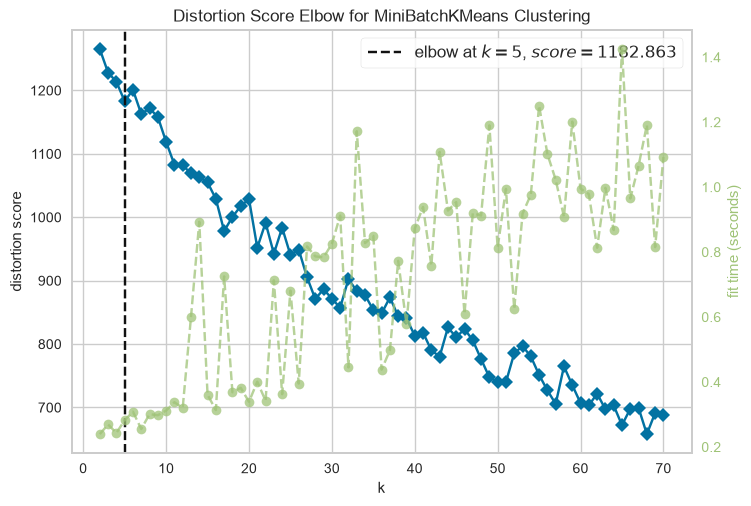

In [49]:
mkelbow = KElbowVisualizer(mkmeans, k=(start, end + 1))
mkelbow.fit(feature_tfidf.toarray())
mkelbow.show()
plt.show()

MiniBatchKMeans로 학습하고, 그 결과를 bcluster 열에 저장한다.

In [52]:
mkmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42)
mkmeans.fit(feature_tfidf)
predict = kmeans.predict(feature_tfidf)
df['bcluster'] = predict

bcluster의 빈도수를 계산한다.

In [76]:
df.bcluster.value_counts().head(10)

bcluster
0     1721
9       46
2       42
5       37
27      31
1       30
3       27
20      25
7       25
11      23
Name: count, dtype: int64

어떤 강의명이 있는지 특정 클러스터의 값을 보자.

In [60]:
df.loc[df.bcluster == 21, 'course'].value_counts().head(1)

course
실전! 스프링 부트와 jpa 활용1 - 웹 애플리케이션 개발    10
Name: count, dtype: int64

In [61]:
df.loc[df.bcluster == 21, ['bcluster', 'cluster', 'course']]

,bcluster,cluster,course
150,21,21,실전! 스프링 부트와 jpa 활용1 - 웹 애플리케이션 개발
217,21,21,"실전! 스프링 부트와 jpa 활용1 - 웹 애플리케이션 개발, 실전! 스프링부트..."
333,21,21,실전! 스프링 부트와 jpa 활용1 - 웹 애플리케이션 개발
374,21,21,실전! 스프링 부트와 jpa 활용1 - 웹 애플리케이션 개발
832,21,21,실전! 스프링 부트와 jpa 활용1 - 웹 애플리케이션 개발
883,21,21,"실전! 스프링 부트와 jpa 활용1 - 웹 애플리케이션 개발, jpa"
918,21,21,실전! 스프링 부트와 jpa 활용1 - 웹 애플리케이션 개발
1191,21,21,실전! 스프링 부트와 jpa 활용1 - 웹 애플리케이션 개발
1214,21,21,실전! 스프링 부트와 jpa 활용1 - 웹 애플리케이션 개발
1220,21,21,실전! 스프링 부트와 jpa 활용1 - 웹 애플리케이션 개발


In [63]:
df.loc[df.bcluster == 30, ['bcluster', 'cluster', 'origin_text', 'course']]

,bcluster,cluster,origin_text,course
115,30,30,데이터를 다루는 일을 하는데 파이선이 필요해서 가입하게 되었습니다\r\n관심강의 :...,"프로그래밍, 데이터 과학을 위한 파이썬 입문"
405,30,30,2020년 공부 목표'\r\n프로그래밍 기초와 데이터 사이언스 기초를 배우고 싶어요...,"'\r\n프로그래밍, 데이터 과학을 위한 파이썬 입문"
749,30,30,"작년 말, 마케터 > 데이터 분석가로 직무를 전환했습니다! 인프런에서 유용한 강의 ...","작년 말, 마케터 > 데이터 분석가로 직무를 전환했습니다! 인프런에서 유용한 강의 ..."
896,30,30,프로그래밍을 배우서 회사 업무를 잘하고 싶어요~\r\n관심강의 : 프로그래밍 데이터...,프로그래밍 데이터 과학을 위한 파이썬 입문
1606,30,30,대학 입학 겸 새로운 도전을 위해 베이스를 탄탄히 하고 싶어요!\r\n\r\n관심강...,"프로그래밍, 데이터 과학을 위한 파이썬 입문"
1735,30,30,로봇개발을 목표로 python을 공부하고 있습니다. 파이썬을 내 마음대로 활용하겠다...,"프로그래밍, 데이터 과학을 위한 파이썬 입문, 머신러닝 이론 및 파이썬 실습 등"


## 클러스터 예측 평가하기

분류, 회귀 모델은 지도학습으로, 정답이 있기 때문에 정답과 예측값을 비교해 볼 수 있다. 하지만 군집화는 비지도학습으로, 정답이 없기 때문에 목적에 따라 평가 방법을 정해야 한다. 이미 앞에서 엘보 법으로 군집간 거리를 계산해서 같은 군집끼리 거리가 가까운지, 다른 군집과 거리가 어느 정도 되는지를 평가했다. 또 군집 결과를 분석해 보면서 평가할 수 있다. 댓글 분석의 목적이 정답이 없는 텍스트를 분류한 것이었다면 비슷한 내용의 텍스트끼리 군집화했는지를 평가한다.

앞에서 구현한 클러스터들의 예측 정확도를 확인해 보자. n_clusters는 위에서 정의한 클래스터 수를 사용한다.

In [69]:
# 사전 준비
# 희소 행렬 형태인 TF-IDF 결과를 계산이 용이한 넘파이 배열 형태로 변환한다.
feature_array = feature_vector.toarray()
# 모델이 분류한 클러스터 번호들에서 중복을 제거한 고유한 라벨 리스트를 가져온다.
labels = np.unique(predict)
# 결과를 저장할 빈 리스트를 선언한다.
df_cluster_score = []
df_cluster = []

넘파이의 where() 메소드는 조건을 만족하는 데이터의 인덱스를 리턴한다.  
넘파이의 argsort() 메소드는 배열의 원소를 직접 정렬하는 대신, 정렬된 상태를 만드는 원본 배열의 인덱스를 리턴한다. 오름차순 정렬

In [115]:
# 클러스터별 반복 분석
for label in labels:
    # 현재 분석 중인 클러스터에 속한 데이터의 인덱스를 찾는다.
    id_temp = np.where(predict == label)
    # 해당 클러스터에 속한 데이터들의 TF-IDF 점수의 평균을 계산한다. 해당 클러스터에서 각 단어가 가지는 평균 중요도가 된다.
    x_means = np.mean(feature_array[id_temp], axis=0)
    # [::-1]: argsort() 메소드로 오름차순 정렬된 결과를 뒤집어서 내림차순 정렬로 만든다.
    # [:n_clusters]: 상위 n_clusters 개수 만큼의 단어 인덱스만 뽑는다.
    sorted_means = np.argsort(x_means)[::-1][:n_clusters]
    # CountVectorizer에서 사용된 실제 단어 리스트를 가져온다.
    features = vectorizer.get_feature_names_out()
    # 인덱스 번호와 실제 단어와 해당 점수의 쌍을 튜플로 변환한 리스트를 만든다.
    beat_features = [(features[i], x_means[i]) for i in sorted_means]
    # 각 클러스터의 상위 단어들을 데이터프레임 형태로 만든다.
    df_score = pd.DataFrame(beat_features, columns=['features', 'score'])
    # 모든 단어 점수 정보를 리스트에 저장한다.
    df_cluster_score.append(df_score)
    # 해당 클러스터에서 가장 점수가 놓은 1등 단어만 뽑아 리스트에 저장한다. 그룹의 대표 키워드
    df_cluster.append(beat_features[0])

점수가 클수록 예측 정화도가 높다. MiniBatchKMenas로 예측한 값을 기준으로 정렬해 각 클러스터에서 점수가 높은 단어를 추출한다.

In [121]:
pd.DataFrame(df_cluster, columns=['features', 'score']).sort_values(by=['features', 'score'], ascending=False)

,features,score
44,화이트해커가 되기 위한 모의해킹 완전 정복,1.000000
5,함수형 프로그래밍과 자바스크립트 es6,1.108108
26,하지만 견고한 자료로,1.000000
17,프로그래밍 핵심 기초,1.000000
46,프로그래밍 시작하기 파이썬 입문,1.000000
6,표준 jpa 프로그래밍 기본편,1.000000
27,표준 jpa 프로그래밍,1.000000
49,파이썬 입문 크롤링을 활용한,1.000000
3,파이썬 실전 활용,1.000000
15,파이썬 머신러닝 완벽가이드,1.000000


In [122]:
df.loc[df.bcluster == 28, ['bcluster', 'cluster', 'origin_text', 'course']]

,bcluster,cluster,origin_text,course
1690,28,28,올해는 TDD 개발 하면서 백엔드 장인으로 거듭나고 싶어요!\r\n관심강의: 테스트...,테스트주도개발(tdd)로 만드는 nodejs api 서버
2163,28,28,2020목표\r\n프런트엔드에 안주하지 않고 백엔드 학습하기\r\nNode.js학습...,테스트주도개발(tdd)로 만드는 nodejs api 서버
2311,28,28,백엔드 개발자 입니다.\r\nJS 풀스택을 공부로 서비스 회사로 이직하고 싶습니다....,테스트주도개발(tdd)로 만드는 nodejs api 서버
2319,28,28,백엔드 개발자 입니다.\r\n회사 업무만 하는 우물안에 개구리에서 벗어나 성장하고 ...,테스트주도개발(tdd)로 만드는 nodejs api 서버
2375,28,28,2020년 공부 목표\r\n- nodeJs 를 이용한 백엔드 구현\r\n관심강의\r...,\r\n- 테스트주도개발(tdd)로 만드는 nodejs api 서버


## 실루엣 계수 분석하기

실수엣 계수 분석은 군집화했을 때 같은 군집 내 샘플 간 거리가 얼마나 가까운지 다른 군집중 가장 가까운 군집과의 거리를 얼마나 먼지를 특정하는 것으로 평가한다. 실루엣 계수는 데이터셋에 대한 실측 정보를 할 수 없을 때 사용하며 계산된 클러스터의 밀도를 계산한다.

In [123]:
from yellowbrick.cluster import SilhouetteVisualizer

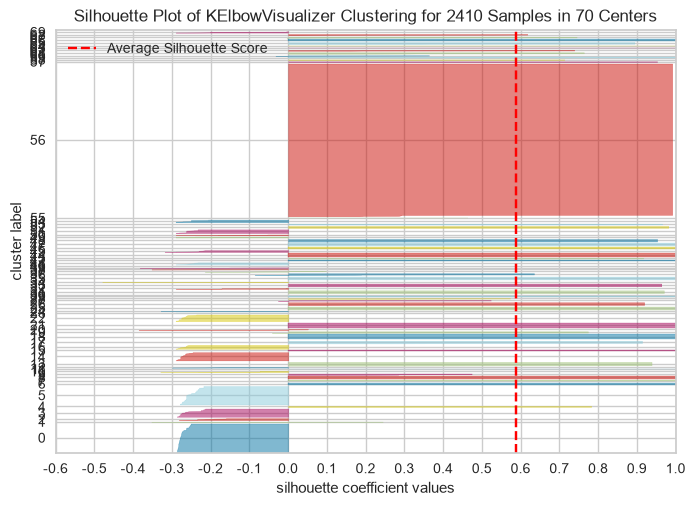

In [128]:
visualizer = SilhouetteVisualizer(mkelbow, colors='yellowbrick')
visualizer.fit(feature_tfidf.toarray())
visualizer.show()
plt.show()

56군집에 너무 많은 데이터가 몰려 있고, 군집의 실루엣 계수가 음수로 나타나는 것들도 있다. 이런 군집은 다른 군집과 겹치는 부분이 많아서 제대로 군집되지 않았음을 나타낸다. 정형 데이터에 비해 비정형 텍스트 데이터를 군집화할 때는 전처리, 정규화, 벡터화 등을 고려해야 한다.